# State-Dependent U.S. Equity Sector Rotation
## A Systematic Framework for Trend-Based Active Sector Allocation

# Block 10 — Weekly Exit-and-Redistribute Audit & Robustness

Block 10 does **not** replace the frozen canonical weekly underweight strategy from Blocks 1–8.

It audits the strongest Block 9 extension:

> **Weekly state signal + bearish sector exit + redistribution across sectors still strategically held**

The objective is to determine whether the apparent improvement is genuine and mechanically sound.

This block performs:

- exact-sample comparison against **SPY, Strategic IV, TSMOM, and canonical State-Dependent**
- execution-lag / timing audit
- explicit handling of the **all-sectors-bearish** edge case
- gross and 5 bps net performance
- wealth and drawdown comparisons
- number of sectors held through time
- maximum single-sector weight and HHI concentration diagnostics
- crisis-window inspection
- worst-week inspection
- subperiod robustness
- leave-one-sector-out robustness
- transaction-cost sensitivity
- audit scorecard and saved research tables

No parameter search is performed.


In [1]:
# ============================================================
# BLOCK 10.1 — ENVIRONMENT, DRIVE & MANIFESTS
# ============================================================

from pathlib import Path
from google.colab import drive
import json
from datetime import datetime, timezone

drive.mount("/content/drive")

PROJECT_ROOT = Path(r"/content/drive/My Drive/Colab Notebooks/Sector Rotation Model/State-Dependent U.S. Equity Sector Rotation - A Systematic Framework for Trend-Based Active Sector Allocation")

DIRS = {
    "data_processed": PROJECT_ROOT / "data" / "processed",
    "tables": PROJECT_ROOT / "outputs" / "tables",
    "figures": PROJECT_ROOT / "outputs" / "figures",
    "manifests": PROJECT_ROOT / "manifests",
}

for p in DIRS.values():
    p.mkdir(parents=True, exist_ok=True)

def load_manifest(filename):
    path = DIRS["manifests"] / filename
    if not path.exists():
        raise FileNotFoundError(path)
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

block1 = load_manifest("block_1_research_configuration.json")
block2 = load_manifest("block_2_universe_data_weights.json")
block3 = load_manifest("block_3_signal_engine.json")
block4 = load_manifest("block_4_state_active_weights.json")
block5 = load_manifest("block_5_portfolio_engine.json")
block6 = load_manifest("block_6_performance_analytics.json")
block8 = load_manifest("block_8_robustness_costs_sensitivity.json")
block9 = load_manifest("block_9_frequency_bearish_exit_extensions.json")

SECTOR_RECORDS = block1["sector_universe"]
SECTOR_COLS = [x["ticker"] for x in SECTOR_RECORDS]
assert len(SECTOR_COLS) == 11

print("Loaded Blocks 1–9.")


Mounted at /content/drive
Loaded Blocks 1–9.


In [2]:
# ============================================================
# BLOCK 10.2 — IMPORTS & SOURCE DATA
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 240)

def resolve_path(mapping, keys, label):
    for key in keys:
        if key in mapping:
            p = Path(mapping[key])
            if p.exists():
                return p
    raise FileNotFoundError(f"Could not resolve {label}; tried {keys}")

STRATEGIC_PATH = resolve_path(
    block2["saved_files"],
    ["strategic_weights", "weekly_strategic_weights"],
    "strategic weights",
)

CALENDAR_PATH = resolve_path(
    block2["saved_files"],
    ["weekly_signal_execution_calendar"],
    "signal/execution calendar",
)

STATE_PATH = resolve_path(
    block4["saved_files"],
    [
        "canonical_active_weights_long",
        "active_weights_long",
        "weekly_state_dependent_active_weights_long",
    ],
    "weekly state table",
)

SECTOR_RETURNS_PATH = resolve_path(
    block5["saved_files"],
    [
        "sector_holding_returns",
        "weekly_execution_holding_returns_sectors",
    ],
    "weekly sector holding returns",
)

CORE_RETURNS_PATH = resolve_path(
    block5["saved_files"],
    [
        "portfolio_returns",
        "weekly_portfolio_returns_core_strategies",
    ],
    "core portfolio returns",
)

TURNOVER_PATH = resolve_path(
    block5["saved_files"],
    [
        "portfolio_turnover",
        "weekly_portfolio_turnover_core_strategies",
    ],
    "core portfolio turnover",
)

strategic = pd.read_parquet(STRATEGIC_PATH)
calendar = pd.read_parquet(CALENDAR_PATH)
state_long = pd.read_parquet(STATE_PATH)
sector_returns = pd.read_parquet(SECTOR_RETURNS_PATH)
core_returns = pd.read_parquet(CORE_RETURNS_PATH)
core_turnover = pd.read_parquet(TURNOVER_PATH)

for df in [strategic, calendar, sector_returns, core_returns, core_turnover]:
    df.index = pd.to_datetime(df.index)
    df.sort_index(inplace=True)

state_long["date"] = pd.to_datetime(state_long["date"])
state_long.sort_values(["ticker", "date"], inplace=True)

print("State columns:", list(state_long.columns))
print("Core return columns:", list(core_returns.columns))


State columns: ['date', 'ticker', 'close', 'smoothed_price', 'fast_ma', 'slow_ma', 'oscillator', 'signal_line', 'spread', 'raw_spread_std', 'spread_std', 'upper_bb', 'lower_bb', 'oscillator_slope', 'signal_slope', 'osc_rising', 'osc_falling', 'signal_rising', 'signal_falling', 'osc_flat', 'signal_flat', 'osc_turns_red', 'cross_below_zero', 'signal_cross_above_zero', 'osc_cross_above_signal', 'osc_cross_above_lower_bb', 'osc_cross_below_upper_bb', 'indicator_ready', 'tsmom_12m_return', 'tsmom_sign', 'signal_observation_date', 'execution_date', 'execution_weekday', 'pine_zone_mode', 'pine_zone_state', 'early_reversal_exit_mode', 'early_reversal_saw_below_bb', 'pullback_saw_above_bb', 'position_held', 'strategic_state', 'tactical_state', 'early_reversal_entry_intersection', 'pullback_entry_intersection', 'start_early_reversal', 'end_early_reversal', 'start_pullback', 'end_pullback', 'start_profit_taking', 'end_profit_taking', 'position_entry_event', 'position_exit_event', 'previous_active

In [3]:
# ============================================================
# BLOCK 10.3 — METRIC HELPERS
# ============================================================

PPY = 52
COST_SCENARIOS_BPS = [0, 5, 10, 20]

def cagr(r):
    if len(r) == 0:
        return np.nan
    terminal = float((1 + r).prod())
    years = len(r) / PPY
    return terminal ** (1 / years) - 1 if terminal > 0 and years > 0 else np.nan

def ann_vol(r):
    return float(r.std(ddof=1) * np.sqrt(PPY))

def sharpe(r):
    sd = r.std(ddof=1)
    return np.nan if sd == 0 or pd.isna(sd) else float(r.mean() / sd * np.sqrt(PPY))

def sortino(r):
    d = r[r < 0]
    if len(d) == 0:
        return np.nan
    ddev = np.sqrt((d ** 2).mean())
    return np.nan if ddev == 0 else float(r.mean() / ddev * np.sqrt(PPY))

def drawdown_series(r):
    wealth = (1 + r).cumprod()
    return wealth / wealth.cummax() - 1

def max_drawdown(r):
    return float(drawdown_series(r).min())

def calmar(r):
    g = cagr(r)
    mdd = max_drawdown(r)
    return np.nan if mdd == 0 or pd.isna(mdd) else float(g / abs(mdd))

def information_ratio(active):
    te = active.std(ddof=1)
    return np.nan if te == 0 or pd.isna(te) else float(active.mean() / te * np.sqrt(PPY))

def summarize(r):
    return {
        "Cumulative Return": float((1 + r).prod() - 1),
        "CAGR": cagr(r),
        "Annualized Volatility": ann_vol(r),
        "Sharpe": sharpe(r),
        "Sortino": sortino(r),
        "Max Drawdown": max_drawdown(r),
        "Calmar": calmar(r),
        "Terminal Wealth": float((1 + r).prod()),
    }

def normalize_rows(df):
    total = df.sum(axis=1)
    return df.div(total.replace(0, np.nan), axis=0)


In [4]:
# ============================================================
# BLOCK 10.4 — RECONSTRUCT HELD / BEARISH MATRIX
# ============================================================

if "positionHeld" in state_long.columns:
    held_long = state_long[["date", "ticker", "positionHeld"]].copy()
    held_long["positionHeld"] = held_long["positionHeld"].astype(bool)
elif "position_held" in state_long.columns:
    held_long = state_long[["date", "ticker", "position_held"]].copy()
    held_long.rename(columns={"position_held": "positionHeld"}, inplace=True)
    held_long["positionHeld"] = held_long["positionHeld"].astype(bool)
else:
    if "strategic_state" not in state_long.columns:
        raise ValueError("Cannot reconstruct strategic held state.")
    held_long = state_long[["date", "ticker", "strategic_state"]].copy()
    held_long["positionHeld"] = held_long["strategic_state"] != "BEARISH"

held = (
    held_long.pivot(index="date", columns="ticker", values="positionHeld")
    .sort_index()
    .astype(float)
)

held = held.reindex(columns=SECTOR_COLS)

assert held.isin([0.0, 1.0]).all().all()

held_count = held.sum(axis=1).astype(int)
all_bearish = held_count == 0

print("Signal weeks:", len(held_count))
print("All-sectors-bearish weeks:", int(all_bearish.sum()))
print("Minimum sectors held:", int(held_count.min()))
print("Median sectors held:", float(held_count.median()))
print("Maximum sectors held:", int(held_count.max()))


Signal weeks: 375
All-sectors-bearish weeks: 52
Minimum sectors held: 0
Median sectors held: 6.0
Maximum sectors held: 9


In [5]:
# ============================================================
# BLOCK 10.5 — EXPLICIT EXIT-REDISTRIBUTE PORTFOLIO
# ============================================================

common_target = strategic.index.intersection(held.index)
base = strategic.reindex(common_target)[SECTOR_COLS]
held_aligned = held.reindex(common_target)[SECTOR_COLS]

raw = base.where(held_aligned > 0.5, 0.0)

# Explicit edge-case rule:
# if all sectors are bearish, hold 100% cash (0% return in this extension).
raw_sum = raw.sum(axis=1)
all_bearish_target = raw_sum == 0

exit_weights = normalize_rows(raw).fillna(0.0)
cash_weight = all_bearish_target.astype(float)
cash_weight.name = "CASH"

assert (exit_weights >= -1e-12).all().all()
assert ((exit_weights.sum(axis=1) + cash_weight) - 1.0).abs().max() < 1e-10

print("Explicit all-bearish target weeks:", int(all_bearish_target.sum()))
print("Weight + cash normalization passed.")


Explicit all-bearish target weeks: 52
Weight + cash normalization passed.


In [6]:
# ============================================================
# BLOCK 10.6 — TIMING / EXECUTION-LAG AUDIT
# ============================================================

# The Block 2 calendar may contain several date-like fields, including
# Friday week labels, actual signal-observation sessions, and execution
# sessions.  For the look-ahead audit we specifically need:
#
#   ACTUAL market session on which the signal was observed
#       <
#   ACTUAL market session on which the rebalance was executed
#
# Do not infer this pair merely from the first column containing "signal"
# because names such as "signal_execution_date" can otherwise be
# misclassified.

cal = calendar.copy()

print("Block 2 signal/execution calendar columns:")
print(list(cal.columns))
print("Calendar index name:", cal.index.name)

# ------------------------------------------------------------
# 1. Resolve execution-session column
# ------------------------------------------------------------

execution_candidates = [
    "execution_date",
    "rebalance_execution_date",
    "next_execution_date",
    "next_trading_session",
    "execution_session",
]

execution_col = next(
    (c for c in execution_candidates if c in cal.columns),
    None,
)

if execution_col is None:
    # Fallback: any date-like execution column.
    possible = [
        c for c in cal.columns
        if "execution" in c.lower()
        and ("date" in c.lower() or "session" in c.lower())
    ]
    if len(possible) == 1:
        execution_col = possible[0]
    elif len(possible) > 1:
        # Prefer a column that does not itself contain "signal".
        nonsignal = [c for c in possible if "signal" not in c.lower()]
        execution_col = nonsignal[0] if nonsignal else possible[0]

if execution_col is None:
    raise ValueError(
        "Could not identify the execution-session column.\n"
        f"Available columns: {list(cal.columns)}"
    )

# ------------------------------------------------------------
# 2. Resolve actual signal-observation session
# ------------------------------------------------------------

signal_candidates = [
    "signal_observation_date",
    "actual_signal_date",
    "signal_session_date",
    "signal_trading_date",
    "observation_date",
    "signal_date",
]

signal_col = next(
    (
        c for c in signal_candidates
        if c in cal.columns and c != execution_col
    ),
    None,
)

if signal_col is None:
    possible = [
        c for c in cal.columns
        if (
            ("signal" in c.lower() or "observation" in c.lower())
            and ("date" in c.lower() or "session" in c.lower())
            and "execution" not in c.lower()
        )
    ]
    if possible:
        # Prefer observation/actual/session fields over week labels.
        def signal_priority(name):
            n = name.lower()
            score = 0
            score += 5 if "observation" in n else 0
            score += 4 if "actual" in n else 0
            score += 3 if "session" in n else 0
            score += 2 if "trading" in n else 0
            score -= 5 if "label" in n else 0
            score -= 3 if "week" in n else 0
            return score

        signal_col = sorted(
            possible,
            key=signal_priority,
            reverse=True,
        )[0]

# If no suitable signal column exists, the calendar index may itself be
# the actual signal session. Use it only as a final fallback.
if signal_col is None:
    cal["__signal_index__"] = pd.to_datetime(cal.index)
    signal_col = "__signal_index__"

# ------------------------------------------------------------
# 3. Build and validate audit table
# ------------------------------------------------------------

signal_dates = pd.to_datetime(cal[signal_col], errors="coerce")
execution_dates = pd.to_datetime(cal[execution_col], errors="coerce")

timing_audit = pd.DataFrame(
    {
        "signal_observation_date": signal_dates.values,
        "execution_date": execution_dates.values,
    },
    index=cal.index,
).dropna(subset=["signal_observation_date", "execution_date"])

timing_audit["lag_calendar_days"] = (
    timing_audit["execution_date"]
    - timing_audit["signal_observation_date"]
).dt.days

timing_audit["strictly_after_signal"] = (
    timing_audit["execution_date"]
    > timing_audit["signal_observation_date"]
)

violations = timing_audit.loc[
    ~timing_audit["strictly_after_signal"]
].copy()

print("\nResolved timing fields:")
print("Signal observation column:", signal_col)
print("Execution column:", execution_col)
print("Audited mappings:", len(timing_audit))
print("Violations:", len(violations))

if len(violations) > 0:
    print("\nFirst timing violations:")
    display(violations.head(10))
    raise AssertionError(
        "Look-ahead timing violation detected after resolving the "
        "actual signal-observation and execution-session fields."
    )

print("\nTiming audit passed.")
print(
    "Minimum calendar-day lag:",
    int(timing_audit["lag_calendar_days"].min()),
)
print(
    "Maximum calendar-day lag:",
    int(timing_audit["lag_calendar_days"].max()),
)
print(
    "Median calendar-day lag:",
    float(timing_audit["lag_calendar_days"].median()),
)


Block 2 signal/execution calendar columns:
['signal_observation_date', 'signal_observation_weekday', 'execution_date', 'execution_weekday', 'calendar_days_signal_to_execution']
Calendar index name: Date

Resolved timing fields:
Signal observation column: signal_observation_date
Execution column: execution_date
Audited mappings: 427
Violations: 0

Timing audit passed.
Minimum calendar-day lag: 3
Maximum calendar-day lag: 4
Median calendar-day lag: 3.0


In [7]:
# ============================================================
# BLOCK 10.7 — REALIZED EXIT-REDISTRIBUTE RETURNS
# ============================================================

realized_index = sector_returns.index.intersection(exit_weights.index)
w_realized = exit_weights.reindex(realized_index)[SECTOR_COLS]
rmat = sector_returns.reindex(realized_index)[SECTOR_COLS]
cash_realized = cash_weight.reindex(realized_index).fillna(0.0)

exit_gross = (w_realized * rmat).sum(axis=1) + cash_realized * 0.0
exit_gross = exit_gross.dropna()

# One-way turnover, consistent with prior blocks.
exit_turnover = (
    0.5 * w_realized.diff().abs().sum(axis=1).fillna(0.0)
    .reindex(exit_gross.index)
)

exit_net5 = exit_gross - exit_turnover * 5 / 10000.0

print("Realized observations:", len(exit_gross))
print("Start:", exit_gross.index.min().date())
print("End:", exit_gross.index.max().date())
print("Annualized turnover approx:", exit_turnover.mean() * 52)


Realized observations: 374
Start: 2019-06-21
End: 2026-08-14
Annualized turnover approx: 1.0906291809203545


In [8]:
# ============================================================
# BLOCK 10.8 — IDENTICAL-SAMPLE COMPARISON
# ============================================================

strategy_names = ["SPY", "Strategic_IV", "TSMOM_12M", "State_Dependent"]

common_idx = exit_gross.index
for s in strategy_names:
    common_idx = common_idx.intersection(core_returns[s].dropna().index)

compare = core_returns.reindex(common_idx)[strategy_names].copy()
compare["Exit_Redistribute"] = exit_gross.reindex(common_idx)

rows = []
for s in compare.columns:
    row = {"Strategy": s, **summarize(compare[s])}
    if s != "SPY":
        row["IR_vs_SPY"] = information_ratio(compare[s] - compare["SPY"])
    else:
        row["IR_vs_SPY"] = np.nan
    if s not in ["Strategic_IV", "SPY"]:
        row["IR_vs_Strategic"] = information_ratio(
            compare[s] - compare["Strategic_IV"]
        )
    else:
        row["IR_vs_Strategic"] = np.nan
    rows.append(row)

gross_comparison = pd.DataFrame(rows).set_index("Strategy")
display(gross_comparison)


,Cumulative Return,CAGR,Annualized Volatility,Sharpe,Sortino,Max Drawdown,Calmar,Terminal Wealth,IR_vs_SPY,IR_vs_Strategic
Strategy,,,,,,,,,,
SPY,1.879664,0.158419,0.186192,0.883955,0.825773,-0.334003,0.474304,2.879664,NaN,NaN
Strategic_IV,1.343816,0.125727,0.171515,0.777031,0.680130,-0.351040,0.358157,2.343816,-0.521742,NaN
TSMOM_12M,1.350249,0.126156,0.168967,0.788368,0.694136,-0.345465,0.365178,2.350249,-0.524259,-0.007002
State_Dependent,1.559913,0.139616,0.173575,0.840655,0.741352,-0.351040,0.397722,2.559913,-0.298084,0.781392
Exit_Redistribute,1.834537,0.155878,0.147510,1.057434,0.908056,-0.172295,0.904716,2.834537,-0.059410,0.169921


In [9]:
# ============================================================
# BLOCK 10.9 — 5 BPS NET COMPARISON
# ============================================================

net5 = compare.copy()

for s in ["Strategic_IV", "TSMOM_12M", "State_Dependent"]:
    t = core_turnover[s].reindex(common_idx).fillna(0.0)
    net5[s] = net5[s] - t * 5 / 10000.0

net5["Exit_Redistribute"] = exit_net5.reindex(common_idx)

rows = []
for s in net5.columns:
    row = {"Strategy": s, **summarize(net5[s])}
    if s != "SPY":
        row["IR_vs_SPY"] = information_ratio(net5[s] - net5["SPY"])
    else:
        row["IR_vs_SPY"] = np.nan
    if s not in ["Strategic_IV", "SPY"]:
        row["IR_vs_Strategic"] = information_ratio(
            net5[s] - net5["Strategic_IV"]
        )
    else:
        row["IR_vs_Strategic"] = np.nan
    rows.append(row)

net5_comparison = pd.DataFrame(rows).set_index("Strategy")
display(net5_comparison)


,Cumulative Return,CAGR,Annualized Volatility,Sharpe,Sortino,Max Drawdown,Calmar,Terminal Wealth,IR_vs_SPY,IR_vs_Strategic
Strategy,,,,,,,,,,
SPY,1.879664,0.158419,0.186192,0.883955,0.825773,-0.334003,0.474304,2.879664,NaN,NaN
Strategic_IV,1.341209,0.125553,0.171514,0.776129,0.681732,-0.351073,0.357627,2.341209,-0.524313,NaN
TSMOM_12M,1.338844,0.125395,0.168957,0.784397,0.690363,-0.345534,0.362902,2.338844,-0.535539,-0.064503
State_Dependent,1.554287,0.139268,0.173573,0.838896,0.739687,-0.351073,0.396691,2.554287,-0.302969,0.771966
Exit_Redistribute,1.823403,0.155246,0.147529,1.053599,0.904272,-0.172698,0.898943,2.823403,-0.063170,0.166987


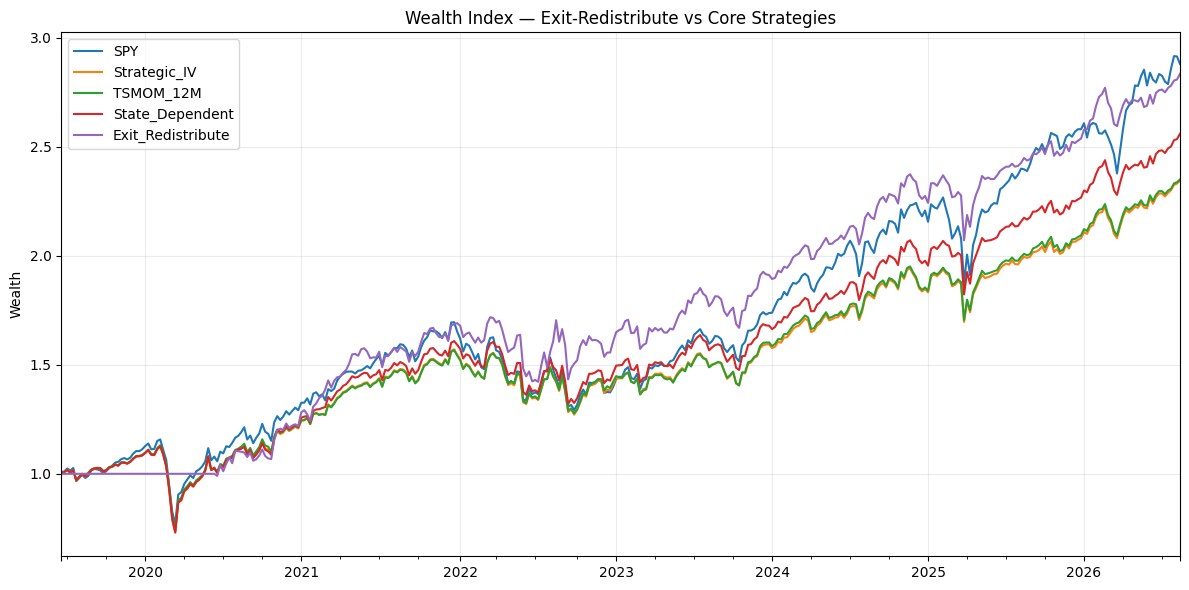

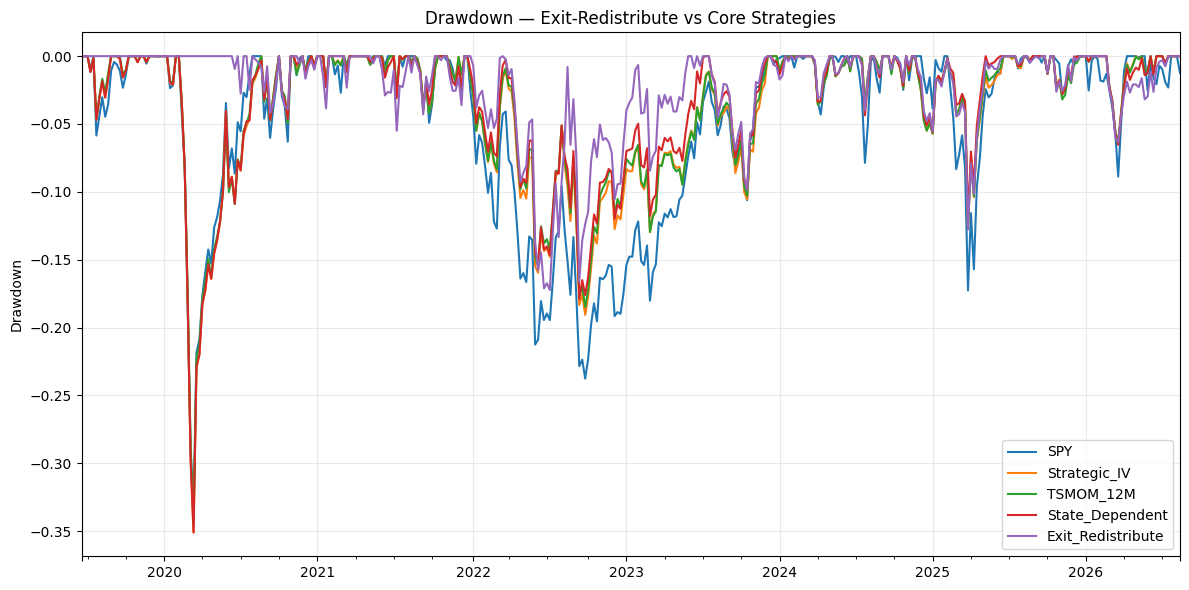

In [10]:
# ============================================================
# BLOCK 10.10 — WEALTH & DRAWDOWN FIGURES
# ============================================================

wealth = (1 + compare).cumprod()

fig, ax = plt.subplots(figsize=(12, 6))
wealth.plot(ax=ax)
ax.set_title("Wealth Index — Exit-Redistribute vs Core Strategies")
ax.set_ylabel("Wealth")
ax.grid(True, alpha=0.25)
fig.tight_layout()

FIG_WEALTH = DIRS["figures"] / "block_10_exit_redistribute_wealth_comparison.png"
fig.savefig(FIG_WEALTH, dpi=180, bbox_inches="tight")
plt.show()

dd = pd.DataFrame({c: drawdown_series(compare[c]) for c in compare.columns})

fig, ax = plt.subplots(figsize=(12, 6))
dd.plot(ax=ax)
ax.set_title("Drawdown — Exit-Redistribute vs Core Strategies")
ax.set_ylabel("Drawdown")
ax.grid(True, alpha=0.25)
fig.tight_layout()

FIG_DD = DIRS["figures"] / "block_10_exit_redistribute_drawdown_comparison.png"
fig.savefig(FIG_DD, dpi=180, bbox_inches="tight")
plt.show()


,Exit-Redistribute concentration audit
Mean sectors held,5.513369
Median sectors held,6.000000
Minimum sectors held,0.000000
Weeks <= 3 sectors held,82.000000
Weeks <= 5 sectors held,182.000000
Mean max sector weight,0.215875
Maximum single-sector weight,1.000000
Mean HHI,0.178195
Mean effective sectors,5.261832
All-cash weeks,52.000000


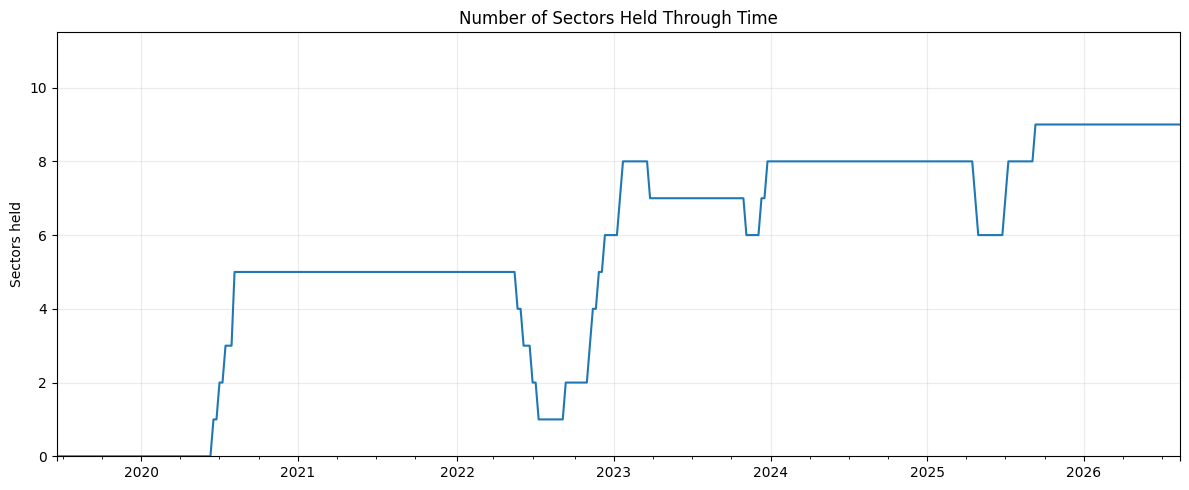

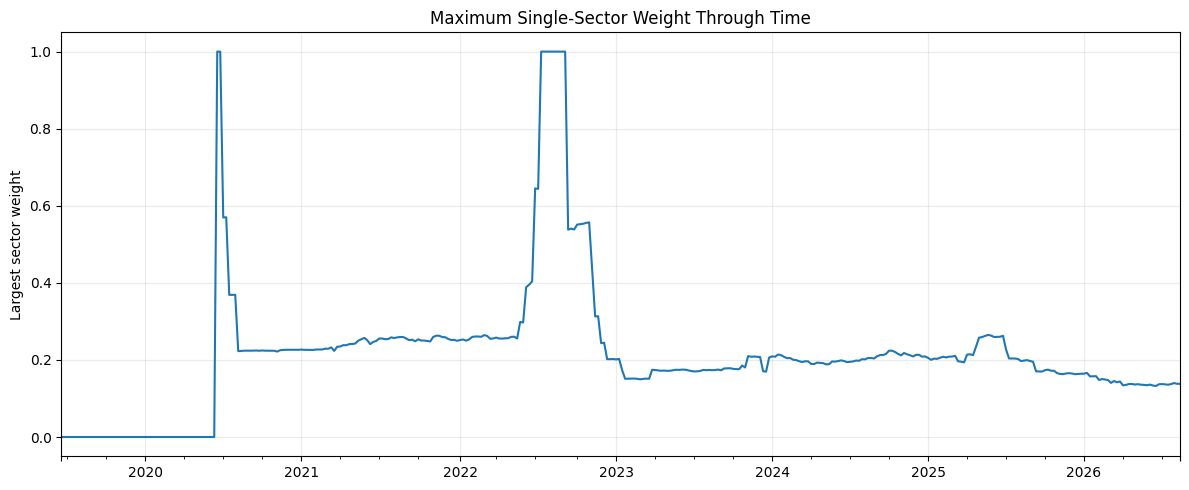

In [11]:
# ============================================================
# BLOCK 10.11 — HOLDINGS & CONCENTRATION DIAGNOSTICS
# ============================================================

w_diag = exit_weights.reindex(common_idx)[SECTOR_COLS]

concentration = pd.DataFrame(index=w_diag.index)
concentration["Sectors_Held"] = (w_diag > 0).sum(axis=1)
concentration["Max_Sector_Weight"] = w_diag.max(axis=1)
concentration["HHI"] = (w_diag ** 2).sum(axis=1)
concentration["Effective_Number_of_Sectors"] = np.where(
    concentration["HHI"] > 0,
    1.0 / concentration["HHI"],
    0.0,
)
concentration["Cash_Weight"] = cash_weight.reindex(common_idx).fillna(0.0)

concentration_summary = pd.Series({
    "Mean sectors held": concentration["Sectors_Held"].mean(),
    "Median sectors held": concentration["Sectors_Held"].median(),
    "Minimum sectors held": concentration["Sectors_Held"].min(),
    "Weeks <= 3 sectors held": int((concentration["Sectors_Held"] <= 3).sum()),
    "Weeks <= 5 sectors held": int((concentration["Sectors_Held"] <= 5).sum()),
    "Mean max sector weight": concentration["Max_Sector_Weight"].mean(),
    "Maximum single-sector weight": concentration["Max_Sector_Weight"].max(),
    "Mean HHI": concentration["HHI"].mean(),
    "Mean effective sectors": concentration["Effective_Number_of_Sectors"].mean(),
    "All-cash weeks": int((concentration["Cash_Weight"] >= 0.999999).sum()),
}, name="Exit-Redistribute concentration audit").to_frame()

display(concentration_summary)

fig, ax = plt.subplots(figsize=(12, 5))
concentration["Sectors_Held"].plot(ax=ax)
ax.set_title("Number of Sectors Held Through Time")
ax.set_ylabel("Sectors held")
ax.set_ylim(0, 11.5)
ax.grid(True, alpha=0.25)
fig.tight_layout()
FIG_HELD = DIRS["figures"] / "block_10_sectors_held_through_time.png"
fig.savefig(FIG_HELD, dpi=180, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(12, 5))
concentration["Max_Sector_Weight"].plot(ax=ax)
ax.set_title("Maximum Single-Sector Weight Through Time")
ax.set_ylabel("Largest sector weight")
ax.grid(True, alpha=0.25)
fig.tight_layout()
FIG_CONC = DIRS["figures"] / "block_10_max_sector_weight_through_time.png"
fig.savefig(FIG_CONC, dpi=180, bbox_inches="tight")
plt.show()


In [12]:
# ============================================================
# BLOCK 10.12 — CRISIS-WINDOW AUDIT
# ============================================================

CRISIS_WINDOWS = {
    "COVID_2020": ("2020-02-01", "2020-06-30"),
    "INFLATION_2022": ("2022-01-01", "2022-12-31"),
}

crisis_rows = []

for name, (start, end) in CRISIS_WINDOWS.items():
    rr = compare.loc[start:end]
    cc = concentration.loc[start:end]

    if len(rr) == 0:
        continue

    crisis_rows.append({
        "Window": name,
        "Start": rr.index.min(),
        "End": rr.index.max(),
        "Exit_Redistribute_Return": float((1 + rr["Exit_Redistribute"]).prod() - 1),
        "Exit_Redistribute_MaxDD": max_drawdown(rr["Exit_Redistribute"]),
        "SPY_Return": float((1 + rr["SPY"]).prod() - 1),
        "SPY_MaxDD": max_drawdown(rr["SPY"]),
        "Mean_Sectors_Held": cc["Sectors_Held"].mean(),
        "Min_Sectors_Held": cc["Sectors_Held"].min(),
        "Max_Single_Sector_Weight": cc["Max_Sector_Weight"].max(),
    })

crisis_summary = pd.DataFrame(crisis_rows).set_index("Window")
display(crisis_summary)

for name, (start, end) in CRISIS_WINDOWS.items():
    print(f"\n{name} — lowest-sector-count weeks")
    display(
        concentration.loc[start:end]
        .sort_values(["Sectors_Held", "Max_Sector_Weight"])
        .head(10)
    )


,Start,End,Exit_Redistribute_Return,Exit_Redistribute_MaxDD,SPY_Return,SPY_MaxDD,Mean_Sectors_Held,Min_Sectors_Held,Max_Single_Sector_Weight
Window,,,,,,,,,
COVID_2020,2020-02-07,2020-06-26,0.040477,-0.009451,-0.042914,-0.334003,0.095238,0,1.0
INFLATION_2022,2022-01-07,2022-12-30,-0.049719,-0.172295,-0.153289,-0.205209,3.557692,1,1.0



COVID_2020 — lowest-sector-count weeks


,Sectors_Held,Max_Sector_Weight,HHI,Effective_Number_of_Sectors,Cash_Weight
2020-02-07,0,0.0,0.0,0.0,1.0
2020-02-14,0,0.0,0.0,0.0,1.0
2020-02-21,0,0.0,0.0,0.0,1.0
2020-02-28,0,0.0,0.0,0.0,1.0
2020-03-06,0,0.0,0.0,0.0,1.0
2020-03-13,0,0.0,0.0,0.0,1.0
2020-03-20,0,0.0,0.0,0.0,1.0
2020-03-27,0,0.0,0.0,0.0,1.0
2020-04-03,0,0.0,0.0,0.0,1.0
2020-04-10,0,0.0,0.0,0.0,1.0



INFLATION_2022 — lowest-sector-count weeks


,Sectors_Held,Max_Sector_Weight,HHI,Effective_Number_of_Sectors,Cash_Weight
2022-07-15,1,1.000000,1.000000,1.00000,0.0
2022-07-22,1,1.000000,1.000000,1.00000,0.0
2022-07-29,1,1.000000,1.000000,1.00000,0.0
2022-08-05,1,1.000000,1.000000,1.00000,0.0
2022-08-12,1,1.000000,1.000000,1.00000,0.0
2022-08-19,1,1.000000,1.000000,1.00000,0.0
2022-08-26,1,1.000000,1.000000,1.00000,0.0
2022-09-02,1,1.000000,1.000000,1.00000,0.0
2022-09-09,1,1.000000,1.000000,1.00000,0.0
2022-09-16,2,0.538058,0.502897,1.98848,0.0


In [13]:
# ============================================================
# BLOCK 10.13 — WORST-WEEK AUDIT
# ============================================================

worst_weeks = pd.DataFrame({
    "Exit_Redistribute": compare["Exit_Redistribute"],
    "SPY": compare["SPY"],
    "Strategic_IV": compare["Strategic_IV"],
    "TSMOM_12M": compare["TSMOM_12M"],
    "State_Dependent": compare["State_Dependent"],
    "Sectors_Held": concentration["Sectors_Held"],
    "Max_Sector_Weight": concentration["Max_Sector_Weight"],
    "Cash_Weight": concentration["Cash_Weight"],
}).sort_values("Exit_Redistribute").head(20)

display(worst_weeks)


,Exit_Redistribute,SPY,Strategic_IV,TSMOM_12M,State_Dependent,Sectors_Held,Max_Sector_Weight,Cash_Weight
2022-09-16,-0.099179,-0.062386,-0.067770,-0.066544,-0.072361,2,0.538058,0.0
2022-06-03,-0.094593,-0.089342,-0.086168,-0.084750,-0.088214,4,0.297258,0.0
2025-03-28,-0.090367,-0.098339,-0.092894,-0.092444,-0.089685,8,0.193570,0.0
2023-03-03,-0.061613,-0.047247,-0.048213,-0.050225,-0.053557,8,0.149601,0.0
2022-08-26,-0.057914,-0.029481,-0.028093,-0.028397,-0.031100,1,1.000000,0.0
2021-07-09,-0.045303,-0.027706,-0.025277,-0.025277,-0.030973,5,0.255548,0.0
2022-09-09,-0.043780,-0.050670,-0.048759,-0.046767,-0.048249,1,1.000000,0.0
2022-07-29,-0.043490,0.005404,0.001981,0.000026,-0.001692,1,1.000000,0.0
2023-10-13,-0.042442,-0.035730,-0.035911,-0.035764,-0.038809,7,0.176214,0.0
2022-12-09,-0.037145,-0.043075,-0.038365,-0.035732,-0.037722,5,0.244575,0.0


In [14]:
# ============================================================
# BLOCK 10.14 — SUBPERIOD ROBUSTNESS
# ============================================================

SUBPERIODS = {
    "2019-2021": ("2019-01-01", "2021-12-31"),
    "2022-2023": ("2022-01-01", "2023-12-31"),
    "2024-End": ("2024-01-01", None),
}

sub_rows = []

for label, (start, end) in SUBPERIODS.items():
    sub = compare.loc[start:end] if end else compare.loc[start:]

    if len(sub) < 10:
        continue

    for strategy in ["SPY", "Strategic_IV", "State_Dependent", "Exit_Redistribute"]:
        row = {
            "Subperiod": label,
            "Strategy": strategy,
            **summarize(sub[strategy]),
        }
        if strategy not in ["SPY", "Strategic_IV"]:
            row["IR_vs_Strategic"] = information_ratio(
                sub[strategy] - sub["Strategic_IV"]
            )
        else:
            row["IR_vs_Strategic"] = np.nan
        sub_rows.append(row)

subperiod_summary = pd.DataFrame(sub_rows).set_index(["Subperiod", "Strategy"])
display(subperiod_summary)


Cumulative Return      CAGR  Annualized Volatility    Sharpe   Sortino  Max Drawdown    Calmar  Terminal Wealth  IR_vs_Strategic
Subperiod Strategy                                                                                                                                           
2019-2021 SPY                         0.652080  0.216873               0.216967  1.013794  0.890711     -0.334003  0.649314         1.652080              NaN
          Strategic_IV                0.546883  0.185970               0.217894  0.891824  0.763013     -0.351040  0.529768         1.546883              NaN
          State_Dependent             0.591980  0.199370               0.219909  0.936869  0.798431     -0.351040  0.567940         1.591980         0.696973
          Exit_Redistribute           0.691099  0.228030               0.129176  1.656418  1.666263     -0.054981  4.147441         1.691099         0.096254
2022-2023 SPY                         0.051814  0.025580               0.183128  0.229334  0.212319     -0.205209  0.124652         1.051814              NaN
          Strategic_IV                0.030360  0.015066               0.165489  0.173183  0.157445     -0.182549  0.082534         1.030360              NaN
          State_Dependent             0.054859  0.027063               0.168747  0.242851  0.225136     -0.176648  0.153206         1.054859         0.658513
          Exit_Redistribute           0.130393  0.063199               0.197789  0.409523  0.359004     -0.172295  0.366810         1.130393         0.507152
2024-End  SPY                         0.657188  0.211338               0.153895  1.324852  1.334292     -0.172681  1.223861         1.657188              NaN
          Strategic_IV                0.470541  0.157625               0.116703  1.314594  1.116441     -0.126707  1.244012         1.470541              NaN
          State_Dependent             0.524379  0.173533               0.117852  1.418920  1.223330     -0.119879  1.447561         1.524379         1.030652
          Exit_Redistribute           0.482804  0.161280               0.117082  1.337601  1.156516     -0.127713  1.262827         1.482804         0.147497

In [15]:
# ============================================================
# BLOCK 10.15 — LEAVE-ONE-SECTOR-OUT ROBUSTNESS
# ============================================================

loo_rows = []

base_realized = strategic.reindex(common_idx)[SECTOR_COLS]
held_realized = held.reindex(common_idx)[SECTOR_COLS]
sector_r_realized = sector_returns.reindex(common_idx)[SECTOR_COLS]

for excluded in SECTOR_COLS:
    keep = [c for c in SECTOR_COLS if c != excluded]

    b = base_realized[keep]
    h = held_realized[keep]

    raw_loo = b.where(h > 0.5, 0.0)
    w_loo = normalize_rows(raw_loo).fillna(0.0)

    r_loo = (w_loo * sector_r_realized[keep]).sum(axis=1)

    # Corresponding leave-one-out strategic baseline.
    strategic_loo = normalize_rows(b)
    strategic_r_loo = (strategic_loo * sector_r_realized[keep]).sum(axis=1)

    loo_rows.append({
        "Excluded_Sector": excluded,
        "CAGR": cagr(r_loo),
        "Sharpe": sharpe(r_loo),
        "Sortino": sortino(r_loo),
        "Max Drawdown": max_drawdown(r_loo),
        "Calmar": calmar(r_loo),
        "IR_vs_Strategic_LOO": information_ratio(r_loo - strategic_r_loo),
        "Terminal Wealth": float((1 + r_loo).prod()),
        "Minimum Sectors Held": int((w_loo > 0).sum(axis=1).min()),
        "Maximum Single-Sector Weight": float(w_loo.max(axis=1).max()),
    })

loo_summary = pd.DataFrame(loo_rows).set_index("Excluded_Sector").sort_index()
display(loo_summary)


,CAGR,Sharpe,Sortino,Max Drawdown,Calmar,IR_vs_Strategic_LOO,Terminal Wealth,Minimum Sectors Held,Maximum Single-Sector Weight
Excluded_Sector,,,,,,,,,
XLB,0.153329,1.042655,0.889512,-0.160606,0.954690,0.147030,2.789891,0,1.0
XLC,0.146500,0.998367,0.885905,-0.172295,0.850287,0.110882,2.673231,0,1.0
XLE,0.116174,0.866153,0.751289,-0.312510,0.371745,-0.091635,2.204459,0,1.0
XLF,0.159992,1.092884,0.946702,-0.161217,0.992403,0.211518,2.907907,0,1.0
XLI,0.156840,1.053116,0.870817,-0.162624,0.964432,0.190833,2.851554,0,1.0
XLK,0.151002,1.034482,0.890548,-0.172295,0.876418,0.213531,2.749658,0,1.0
XLP,0.161831,1.066123,0.930194,-0.172295,0.939270,0.154046,2.941232,0,1.0
XLRE,0.156763,1.022251,0.909575,-0.213779,0.733297,0.143162,2.850191,0,1.0
XLU,0.155682,1.049501,0.916519,-0.172295,0.903578,0.154473,2.831079,0,1.0


In [16]:
# ============================================================
# BLOCK 10.16 — TRANSACTION-COST ROBUSTNESS
# ============================================================

cost_rows = []

for bps in COST_SCENARIOS_BPS:
    r = exit_gross.reindex(common_idx) - exit_turnover.reindex(common_idx).fillna(0.0) * bps / 10000.0

    cost_rows.append({
        "Cost_bps": bps,
        **summarize(r),
        "IR_vs_SPY": information_ratio(r - compare["SPY"]),
        "IR_vs_Strategic": information_ratio(r - compare["Strategic_IV"]),
    })

cost_summary = pd.DataFrame(cost_rows).set_index("Cost_bps")
display(cost_summary)


,Cumulative Return,CAGR,Annualized Volatility,Sharpe,Sortino,Max Drawdown,Calmar,Terminal Wealth,IR_vs_SPY,IR_vs_Strategic
Cost_bps,,,,,,,,,,
0,1.834537,0.155878,0.147510,1.057434,0.908056,-0.172295,0.904716,2.834537,-0.059410,0.169921
5,1.823403,0.155246,0.147529,1.053599,0.904272,-0.172698,0.898943,2.823403,-0.063170,0.165828
10,1.812312,0.154614,0.147549,1.049761,0.900489,-0.173101,0.893200,2.812312,-0.066930,0.161735
20,1.790255,0.153350,0.147591,1.042078,0.896550,-0.173906,0.881800,2.790255,-0.074447,0.153549


In [17]:
# ============================================================
# BLOCK 10.17 — AUDIT SCORECARD
# ============================================================

audit_scorecard = pd.Series({
    "Timing lag strictly positive": bool(timing_audit["strictly_after_signal"].dropna().all()),
    "All-bearish signal weeks": int(all_bearish.sum()),
    "All-bearish realized weeks": int((concentration["Cash_Weight"] >= 0.999999).sum()),
    "Gross CAGR": gross_comparison.loc["Exit_Redistribute", "CAGR"],
    "Gross Sharpe": gross_comparison.loc["Exit_Redistribute", "Sharpe"],
    "Gross Max Drawdown": gross_comparison.loc["Exit_Redistribute", "Max Drawdown"],
    "Gross IR vs SPY": gross_comparison.loc["Exit_Redistribute", "IR_vs_SPY"],
    "Gross IR vs Strategic": gross_comparison.loc["Exit_Redistribute", "IR_vs_Strategic"],
    "5bps CAGR": net5_comparison.loc["Exit_Redistribute", "CAGR"],
    "5bps Sharpe": net5_comparison.loc["Exit_Redistribute", "Sharpe"],
    "5bps Max Drawdown": net5_comparison.loc["Exit_Redistribute", "Max Drawdown"],
    "Annualized turnover approx": exit_turnover.mean() * 52,
    "Minimum sectors held": concentration["Sectors_Held"].min(),
    "Maximum single-sector weight": concentration["Max_Sector_Weight"].max(),
    "LOO positive IR count": int((loo_summary["IR_vs_Strategic_LOO"] > 0).sum()),
    "LOO tests": len(loo_summary),
}, name="Block 10 audit scorecard").to_frame()

display(audit_scorecard)


,Block 10 audit scorecard
Timing lag strictly positive,True
All-bearish signal weeks,52
All-bearish realized weeks,52
Gross CAGR,0.155878
Gross Sharpe,1.057434
Gross Max Drawdown,-0.172295
Gross IR vs SPY,-0.05941
Gross IR vs Strategic,0.169921
5bps CAGR,0.155246
5bps Sharpe,1.053599


In [18]:
# ============================================================
# BLOCK 10.18 — SAVE TABLES
# ============================================================

TABLE_PATHS = {
    "gross_comparison": DIRS["tables"] / "block_10_gross_comparison.csv",
    "net5_comparison": DIRS["tables"] / "block_10_net5_comparison.csv",
    "timing_audit": DIRS["tables"] / "block_10_timing_audit.csv",
    "concentration": DIRS["tables"] / "block_10_concentration_diagnostics.csv",
    "concentration_summary": DIRS["tables"] / "block_10_concentration_summary.csv",
    "crisis_summary": DIRS["tables"] / "block_10_crisis_summary.csv",
    "worst_weeks": DIRS["tables"] / "block_10_worst_weeks.csv",
    "subperiod_summary": DIRS["tables"] / "block_10_subperiod_summary.csv",
    "leave_one_out": DIRS["tables"] / "block_10_leave_one_sector_out.csv",
    "cost_summary": DIRS["tables"] / "block_10_cost_summary.csv",
    "audit_scorecard": DIRS["tables"] / "block_10_audit_scorecard.csv",
}

gross_comparison.to_csv(TABLE_PATHS["gross_comparison"])
net5_comparison.to_csv(TABLE_PATHS["net5_comparison"])
timing_audit.to_csv(TABLE_PATHS["timing_audit"])
concentration.to_csv(TABLE_PATHS["concentration"])
concentration_summary.to_csv(TABLE_PATHS["concentration_summary"])
crisis_summary.to_csv(TABLE_PATHS["crisis_summary"])
worst_weeks.to_csv(TABLE_PATHS["worst_weeks"])
subperiod_summary.to_csv(TABLE_PATHS["subperiod_summary"])
loo_summary.to_csv(TABLE_PATHS["leave_one_out"])
cost_summary.to_csv(TABLE_PATHS["cost_summary"])
audit_scorecard.to_csv(TABLE_PATHS["audit_scorecard"])

WEIGHTS_PATH = DIRS["data_processed"] / "weekly_exit_redistribute_target_weights.parquet"
RETURNS_PATH = DIRS["data_processed"] / "weekly_exit_redistribute_returns.parquet"

exit_weights.to_parquet(WEIGHTS_PATH)
pd.DataFrame({
    "Gross": exit_gross,
    "Net_5bps": exit_net5,
    "Turnover": exit_turnover,
}).to_parquet(RETURNS_PATH)

print("Saved Block 10 outputs.")


Saved Block 10 outputs.


In [19]:
# ============================================================
# BLOCK 10.19 — MANIFEST & FINAL STATUS
# ============================================================

manifest = {
    "project": block1["project"],
    "block": "Block 10 - Weekly Exit-and-Redistribute Audit & Robustness",
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "architecture": {
        "signal_frequency": "WEEKLY",
        "bearish_treatment": "EXIT_REDISTRIBUTE",
        "all_bearish_fallback": "100_PERCENT_CASH_ZERO_RETURN",
        "transaction_cost_bps_canonical": 5,
    },
    "comparison_window": {
        "start": str(common_idx.min().date()),
        "end": str(common_idx.max().date()),
        "observations": int(len(common_idx)),
    },
    "tables": {k: str(v) for k, v in TABLE_PATHS.items()},
    "figures": {
        "wealth": str(FIG_WEALTH),
        "drawdown": str(FIG_DD),
        "sectors_held": str(FIG_HELD),
        "max_sector_weight": str(FIG_CONC),
    },
    "saved_files": {
        "target_weights": str(WEIGHTS_PATH),
        "returns": str(RETURNS_PATH),
    },
}

MANIFEST_PATH = DIRS["manifests"] / "block_10_exit_redistribute_audit_robustness.json"

with open(MANIFEST_PATH, "w", encoding="utf-8") as f:
    json.dump(manifest, f, indent=2)

status = pd.Series({
    "Timing audit passed": bool(timing_audit["strictly_after_signal"].dropna().all()),
    "Gross comparison saved": TABLE_PATHS["gross_comparison"].exists(),
    "5bps comparison saved": TABLE_PATHS["net5_comparison"].exists(),
    "Concentration audit saved": TABLE_PATHS["concentration_summary"].exists(),
    "Subperiod audit saved": TABLE_PATHS["subperiod_summary"].exists(),
    "Leave-one-out audit saved": TABLE_PATHS["leave_one_out"].exists(),
    "Cost audit saved": TABLE_PATHS["cost_summary"].exists(),
    "All figures saved": all(p.exists() for p in [FIG_WEALTH, FIG_DD, FIG_HELD, FIG_CONC]),
}, name="Block 10 status").to_frame()

display(status)

print("\nBLOCK 10 COMPLETE")
print("Next: interpret whether Exit-Redistribute survives the audit.")


,Block 10 status
Timing audit passed,True
Gross comparison saved,True
5bps comparison saved,True
Concentration audit saved,True
Subperiod audit saved,True
Leave-one-out audit saved,True
Cost audit saved,True
All figures saved,True



BLOCK 10 COMPLETE
Next: interpret whether Exit-Redistribute survives the audit.
